# Análisis de Diferencias entre Menores y Mayores de Edad

Este notebook analiza si existen diferencias significativas entre pacientes pediátricos (menores de 18 años) y adultos (mayores de 18 años) en el contexto de:
- Distribuciones de variables
- Clustering y detección de anomalías
- Validación de si se debe separar el modelo en dos: pediátricos y adultos


## 1. Importación de librerías


In [39]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency, ttest_ind
import warnings
warnings.filterwarnings('ignore')

# Para análisis avanzado
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Configuración de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Librerías importadas correctamente")


Librerías importadas correctamente


In [ ]:
def obtener_columnas_numericas(df, excluir_identificadores=True):
    """
    Obtiene todas las columnas numéricas del dataset, excluyendo identificadores.
    
    Args:
        df: DataFrame con los datos
        excluir_identificadores: Si True, excluye columnas de identificación
    
    Returns:
        Lista de nombres de columnas numéricas
    """
    # Columnas a excluir (identificadores)
    columnas_excluir = [
        'Documento PMD', 'Número de episodio', 'Nombres y Apellidos',
        'Tipo de identificación', 'Número de identificación'
    ] if excluir_identificadores else []
    
    # Obtener todas las columnas numéricas
    columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Excluir identificadores y columnas que no queremos analizar
    columnas_numericas = [
        col for col in columnas_numericas 
        if col not in columnas_excluir and 'anio' not in col.lower()
    ]
    
    return columnas_numericas


def separar_por_edad(df, edad_col='Edad', umbral=18):
    """
    Separa el dataset en pediátricos y adultos.
    
    Args:
        df: DataFrame con los datos
        edad_col: Nombre de la columna de edad
        umbral: Edad umbral para separar (default: 18)
    
    Returns:
        Tupla (df_pediatricos, df_adultos)
    """
    if edad_col not in df.columns:
        raise ValueError(f"La columna '{edad_col}' no existe en el dataset")
    
    df_pediatricos = df[df[edad_col] < umbral].copy()
    df_adultos = df[df[edad_col] >= umbral].copy()
    
    return df_pediatricos, df_adultos


print("✓ Funciones auxiliares definidas")


✓ Funciones auxiliares definidas


## 2. Carga de datos y funciones auxiliares


In [41]:
# ============================================================================
# CARGA DE DATOS
# ============================================================================

# Cargar dataset limpio (para análisis numérico y clustering)
print("=" * 80)
print("CARGANDO DATASET LIMPIO")
print("=" * 80)
try:
    df_clean = pd.read_csv('df_clean.csv')
    print(f"✓ Dataset limpio cargado: {df_clean.shape[0]} filas × {df_clean.shape[1]} columnas")
except FileNotFoundError:
    try:
        df_clean = pd.read_csv('../df_clean.csv')
        print(f"✓ Dataset limpio cargado: {df_clean.shape[0]} filas × {df_clean.shape[1]} columnas")
    except FileNotFoundError:
        print("✗ Error: No se encontró el archivo df_clean.csv")
        df_clean = None

# Cargar dataset original (para análisis categórico)
print("\n" + "=" * 80)
print("CARGANDO DATASET ORIGINAL (para análisis categórico)")
print("=" * 80)
try:
    df_original = pd.read_excel('../../OPERA_BASE.xlsx')
    print(f"✓ Dataset original cargado: {df_original.shape[0]} filas × {df_original.shape[1]} columnas")
except FileNotFoundError:
    try:
        df_original = pd.read_excel('../OPERA_BASE.xlsx')
        print(f"✓ Dataset original cargado: {df_original.shape[0]} filas × {df_original.shape[1]} columnas")
    except FileNotFoundError:
        print("⚠ Advertencia: No se encontró el archivo OPERA_BASE.xlsx")
        print("  El análisis de variables categóricas no se podrá realizar")
        df_original = None

# Obtener todas las columnas numéricas del dataset limpio
if df_clean is not None:
    columnas_numericas_completas = obtener_columnas_numericas(df_clean, excluir_identificadores=True)
    print(f"\n✓ Columnas numéricas para análisis: {len(columnas_numericas_completas)}")
    print(f"  Primeras 10: {columnas_numericas_completas[:10]}")
    if len(columnas_numericas_completas) > 10:
        print(f"  Últimas 10: {columnas_numericas_completas[-10:]}")


CARGANDO DATASET LIMPIO


✓ Dataset limpio cargado: 30962 filas × 242 columnas

CARGANDO DATASET ORIGINAL (para análisis categórico)
✓ Dataset original cargado: 30962 filas × 64 columnas

✓ Columnas numéricas para análisis: 216
  Primeras 10: ['Edad', 'Peso (Kg)', 'Talla (cm)', 'IMC', 'Antecedentes anestésicos', 'Tensión Arterial Sistólica (mm/Hg)', 'Tensión Arterial Diastólica (mm/Hg)', 'Tensión Arterial Media (mm/Hg)', 'Frecuencia Respiratoria', 'Temperatura']
  Últimas 10: ['Antecedentes quirúrgicos Code_K', 'Antecedentes quirúrgicos Code_L', 'Antecedentes quirúrgicos Code_M', 'Antecedentes quirúrgicos Code_NO ENCONTRADO', 'Antecedentes quirúrgicos Code_P', 'Antecedentes quirúrgicos Code_Q', 'Antecedentes quirúrgicos Code_S', 'Antecedentes quirúrgicos Code_T', 'Antecedentes quirúrgicos Code_V', 'Antecedentes quirúrgicos Code_None']


## 3. Separación por grupos de edad


DISTRIBUCIÓN POR GRUPOS DE EDAD
Total de registros: 30962
Pediátricos (< 18 años): 6683 (21.58%)
Adultos (≥ 18 años): 24279 (78.42%)

ESTADÍSTICAS DE EDAD POR GRUPO

Pediátricos:
count    6683.000000
mean        8.537782
std         5.332848
min         0.000000
25%         4.000000
50%         8.000000
75%        14.000000
max        17.000000
Name: Edad, dtype: float64

Adultos:
count    24279.000000
mean        46.078629
std         15.861576
min         18.000000
25%         34.000000
50%         44.000000
75%         57.000000
max        101.000000
Name: Edad, dtype: float64


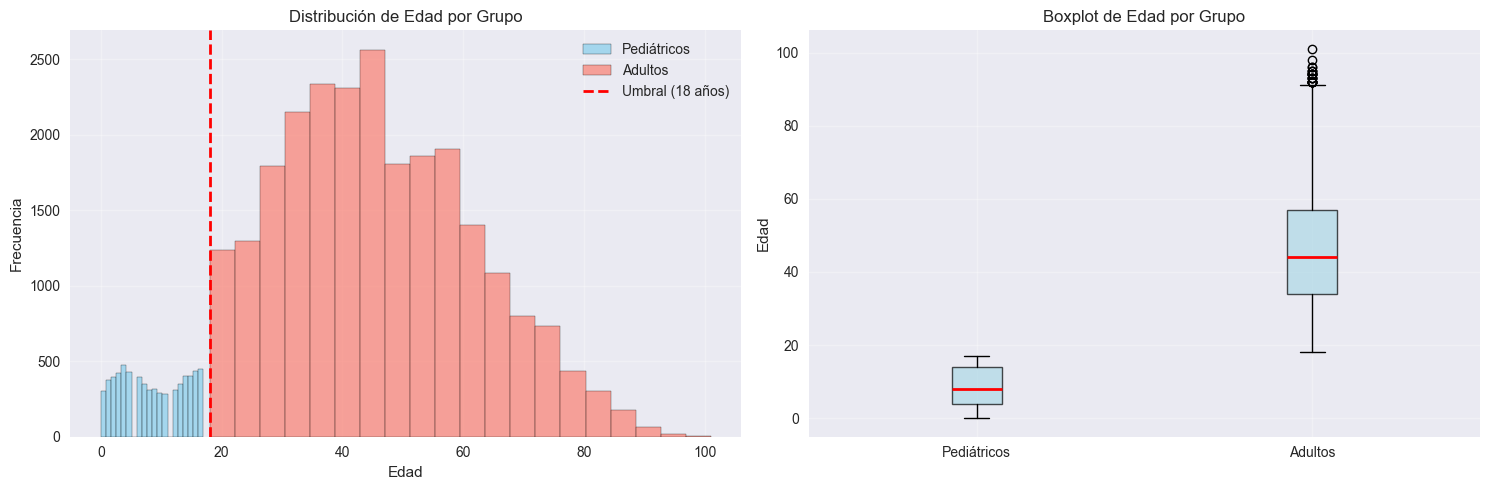

In [42]:
# ============================================================================
# SEPARACIÓN POR GRUPOS DE EDAD
# ============================================================================

EDAD_UMBRAL = 18

if df_clean is not None and 'Edad' in df_clean.columns:
    # Separar usando la función reutilizable
    df_pediatricos, df_adultos = separar_por_edad(df_clean, edad_col='Edad', umbral=EDAD_UMBRAL)
    
    # Crear variable de grupo de edad
    df_clean['Grupo_Edad'] = df_clean['Edad'].apply(lambda x: 'Pediatrico' if x < EDAD_UMBRAL else 'Adulto')
    
    print("=" * 80)
    print("DISTRIBUCIÓN POR GRUPOS DE EDAD")
    print("=" * 80)
    print(f"Total de registros: {len(df_clean)}")
    print(f"Pediátricos (< {EDAD_UMBRAL} años): {len(df_pediatricos)} ({len(df_pediatricos)/len(df_clean)*100:.2f}%)")
    print(f"Adultos (≥ {EDAD_UMBRAL} años): {len(df_adultos)} ({len(df_adultos)/len(df_clean)*100:.2f}%)")
    
    # Estadísticas de edad por grupo
    print("\n" + "=" * 80)
    print("ESTADÍSTICAS DE EDAD POR GRUPO")
    print("=" * 80)
    print("\nPediátricos:")
    print(df_pediatricos['Edad'].describe())
    print("\nAdultos:")
    print(df_adultos['Edad'].describe())
    
    # Distribución de edad
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Histograma
    axes[0].hist(df_pediatricos['Edad'], bins=20, alpha=0.7, label='Pediátricos', color='skyblue', edgecolor='black')
    axes[0].hist(df_adultos['Edad'], bins=20, alpha=0.7, label='Adultos', color='salmon', edgecolor='black')
    axes[0].axvline(EDAD_UMBRAL, color='red', linestyle='--', linewidth=2, label=f'Umbral ({EDAD_UMBRAL} años)')
    axes[0].set_xlabel('Edad')
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_title('Distribución de Edad por Grupo')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Boxplot
    data_to_plot = [df_pediatricos['Edad'], df_adultos['Edad']]
    axes[1].boxplot(data_to_plot, labels=['Pediátricos', 'Adultos'], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[1].set_ylabel('Edad')
    axes[1].set_title('Boxplot de Edad por Grupo')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("✗ Error: No se pudo cargar el dataset o la columna 'Edad' no existe")


In [ ]:
# ============================================================================
# OBTENER COLUMNAS NUMÉRICAS PARA ANÁLISIS
# ============================================================================

if df_clean is not None:
    # Obtener todas las columnas numéricas usando la función reutilizable
    numeric_columns = obtener_columnas_numericas(df_clean, excluir_identificadores=True)
    
    # Excluir 'Edad' de la comparación estadística (ya sabemos que es diferente)
    numeric_columns = [col for col in numeric_columns if col != 'Edad']
    
    print(f"✓ Columnas numéricas para comparación: {len(numeric_columns)}")
    print(f"  (Excluyendo Edad e identificadores)")
else:
    numeric_columns = []
    print("✗ Error: No se pudo obtener columnas numéricas")

def comparar_variables_numericas(df_ped, df_adu, columnas):
    """Compara variables numéricas entre grupos usando pruebas estadísticas"""
    resultados = []
    
    for col in columnas:
        # Filtrar valores válidos
        ped_vals = df_ped[col].dropna()
        adu_vals = df_adu[col].dropna()
        
        if len(ped_vals) == 0 or len(adu_vals) == 0:
            continue
            
        # Estadísticas descriptivas
        stats_ped = {
            'media': ped_vals.mean(),
            'mediana': ped_vals.median(),
            'std': ped_vals.std(),
            'min': ped_vals.min(),
            'max': ped_vals.max(),
            'n': len(ped_vals)
        }
        
        stats_adu = {
            'media': adu_vals.mean(),
            'mediana': adu_vals.median(),
            'std': adu_vals.std(),
            'min': adu_vals.min(),
            'max': adu_vals.max(),
            'n': len(adu_vals)
        }
        
        # Pruebas estadísticas
        # Test de normalidad (Shapiro-Wilk, solo si hay suficientes datos)
        normal_ped = False
        normal_adu = False
        if len(ped_vals) >= 3 and len(ped_vals) <= 5000:
            try:
                _, p_ped = stats.shapiro(ped_vals.sample(min(5000, len(ped_vals))))
                normal_ped = p_ped > 0.05
            except:
                pass
        if len(adu_vals) >= 3 and len(adu_vals) <= 5000:
            try:
                _, p_adu = stats.shapiro(adu_vals.sample(min(5000, len(adu_vals))))
                normal_adu = p_adu > 0.05
            except:
                pass
        
        # Elegir prueba según normalidad
        if normal_ped and normal_adu and len(ped_vals) > 30 and len(adu_vals) > 30:
            # T-test (ambos normales)
            stat, p_value = ttest_ind(ped_vals, adu_vals)
            test_usado = 't-test'
        else:
            # Mann-Whitney U (no paramétrico)
            stat, p_value = mannwhitneyu(ped_vals, adu_vals, alternative='two-sided')
            test_usado = 'Mann-Whitney U'
        
        # Tamaño del efecto (Cohen's d)
        pooled_std = np.sqrt(((len(ped_vals) - 1) * ped_vals.std()**2 + 
                             (len(adu_vals) - 1) * adu_vals.std()**2) / 
                            (len(ped_vals) + len(adu_vals) - 2))
        cohens_d = (stats_ped['media'] - stats_adu['media']) / pooled_std if pooled_std > 0 else 0
        
        resultados.append({
            'Variable': col,
            'Media_Ped': f"{stats_ped['media']:.2f}",
            'Media_Adu': f"{stats_adu['media']:.2f}",
            'Diferencia': f"{stats_ped['media'] - stats_adu['media']:.2f}",
            'Mediana_Ped': f"{stats_ped['mediana']:.2f}",
            'Mediana_Adu': f"{stats_adu['mediana']:.2f}",
            'Std_Ped': f"{stats_ped['std']:.2f}",
            'Std_Adu': f"{stats_adu['std']:.2f}",
            'N_Ped': stats_ped['n'],
            'N_Adu': stats_adu['n'],
            'Test': test_usado,
            'p_value': f"{p_value:.6f}",
            'Significativo': 'Sí' if p_value < 0.05 else 'No',
            'Cohens_d': f"{cohens_d:.3f}",
            'Tamaño_Efecto': 'Grande' if abs(cohens_d) > 0.8 else 'Mediano' if abs(cohens_d) > 0.5 else 'Pequeño' if abs(cohens_d) > 0.2 else 'Muy pequeño'
        })
    
    return pd.DataFrame(resultados)

if df_clean is not None and 'Edad' in df_clean.columns and len(numeric_columns) > 0:
    # Limitar a las primeras 50 variables más importantes para visualización
    # (todas las variables se usarán en clustering/anomalías)
    numeric_columns_para_comparacion = numeric_columns[:50] if len(numeric_columns) > 50 else numeric_columns
    resultados_comparacion = comparar_variables_numericas(df_pediatricos, df_adultos, numeric_columns_para_comparacion)
    print("=" * 120)
    print("COMPARACIÓN ESTADÍSTICA DE VARIABLES NUMÉRICAS")
    print("=" * 120)
    print(resultados_comparacion.to_string(index=False))
    
    # Resumen de diferencias significativas
    print("\n" + "=" * 120)
    print("RESUMEN: VARIABLES CON DIFERENCIAS SIGNIFICATIVAS (p < 0.05)")
    print("=" * 120)
    significativas = resultados_comparacion[resultados_comparacion['Significativo'] == 'Sí']
    if len(significativas) > 0:
        print(significativas[['Variable', 'Diferencia', 'p_value', 'Tamaño_Efecto']].to_string(index=False))
    else:
        print("No se encontraron diferencias significativas.")


✓ Columnas numéricas para comparación: 215
  (Excluyendo Edad e identificadores)
COMPARACIÓN ESTADÍSTICA DE VARIABLES NUMÉRICAS
                                       Variable Media_Ped Media_Adu Diferencia Mediana_Ped Mediana_Adu Std_Ped Std_Adu  N_Ped  N_Adu           Test  p_value Significativo Cohens_d Tamaño_Efecto
                                      Peso (Kg)     36.69     79.57     -42.88       30.39       71.00   18.72   31.18   6683  24279 Mann-Whitney U 0.000000            Sí   -1.481        Grande
                                     Talla (cm)    124.10    166.86     -42.77      112.81      165.00   31.56   10.41   6683  24279 Mann-Whitney U 0.000000            Sí   -2.469        Grande
                                            IMC     18.47     25.95      -7.48       17.68       25.97    2.73    3.56   6683  24279 Mann-Whitney U 0.000000            Sí   -2.203        Grande
                       Antecedentes anestésicos    761.16   1261.22    -500.06        0.00     2


Nota: Mostrando solo las primeras 9 variables de 215 totales
     Todas las 215 variables se usarán en el análisis de clustering/anomalías


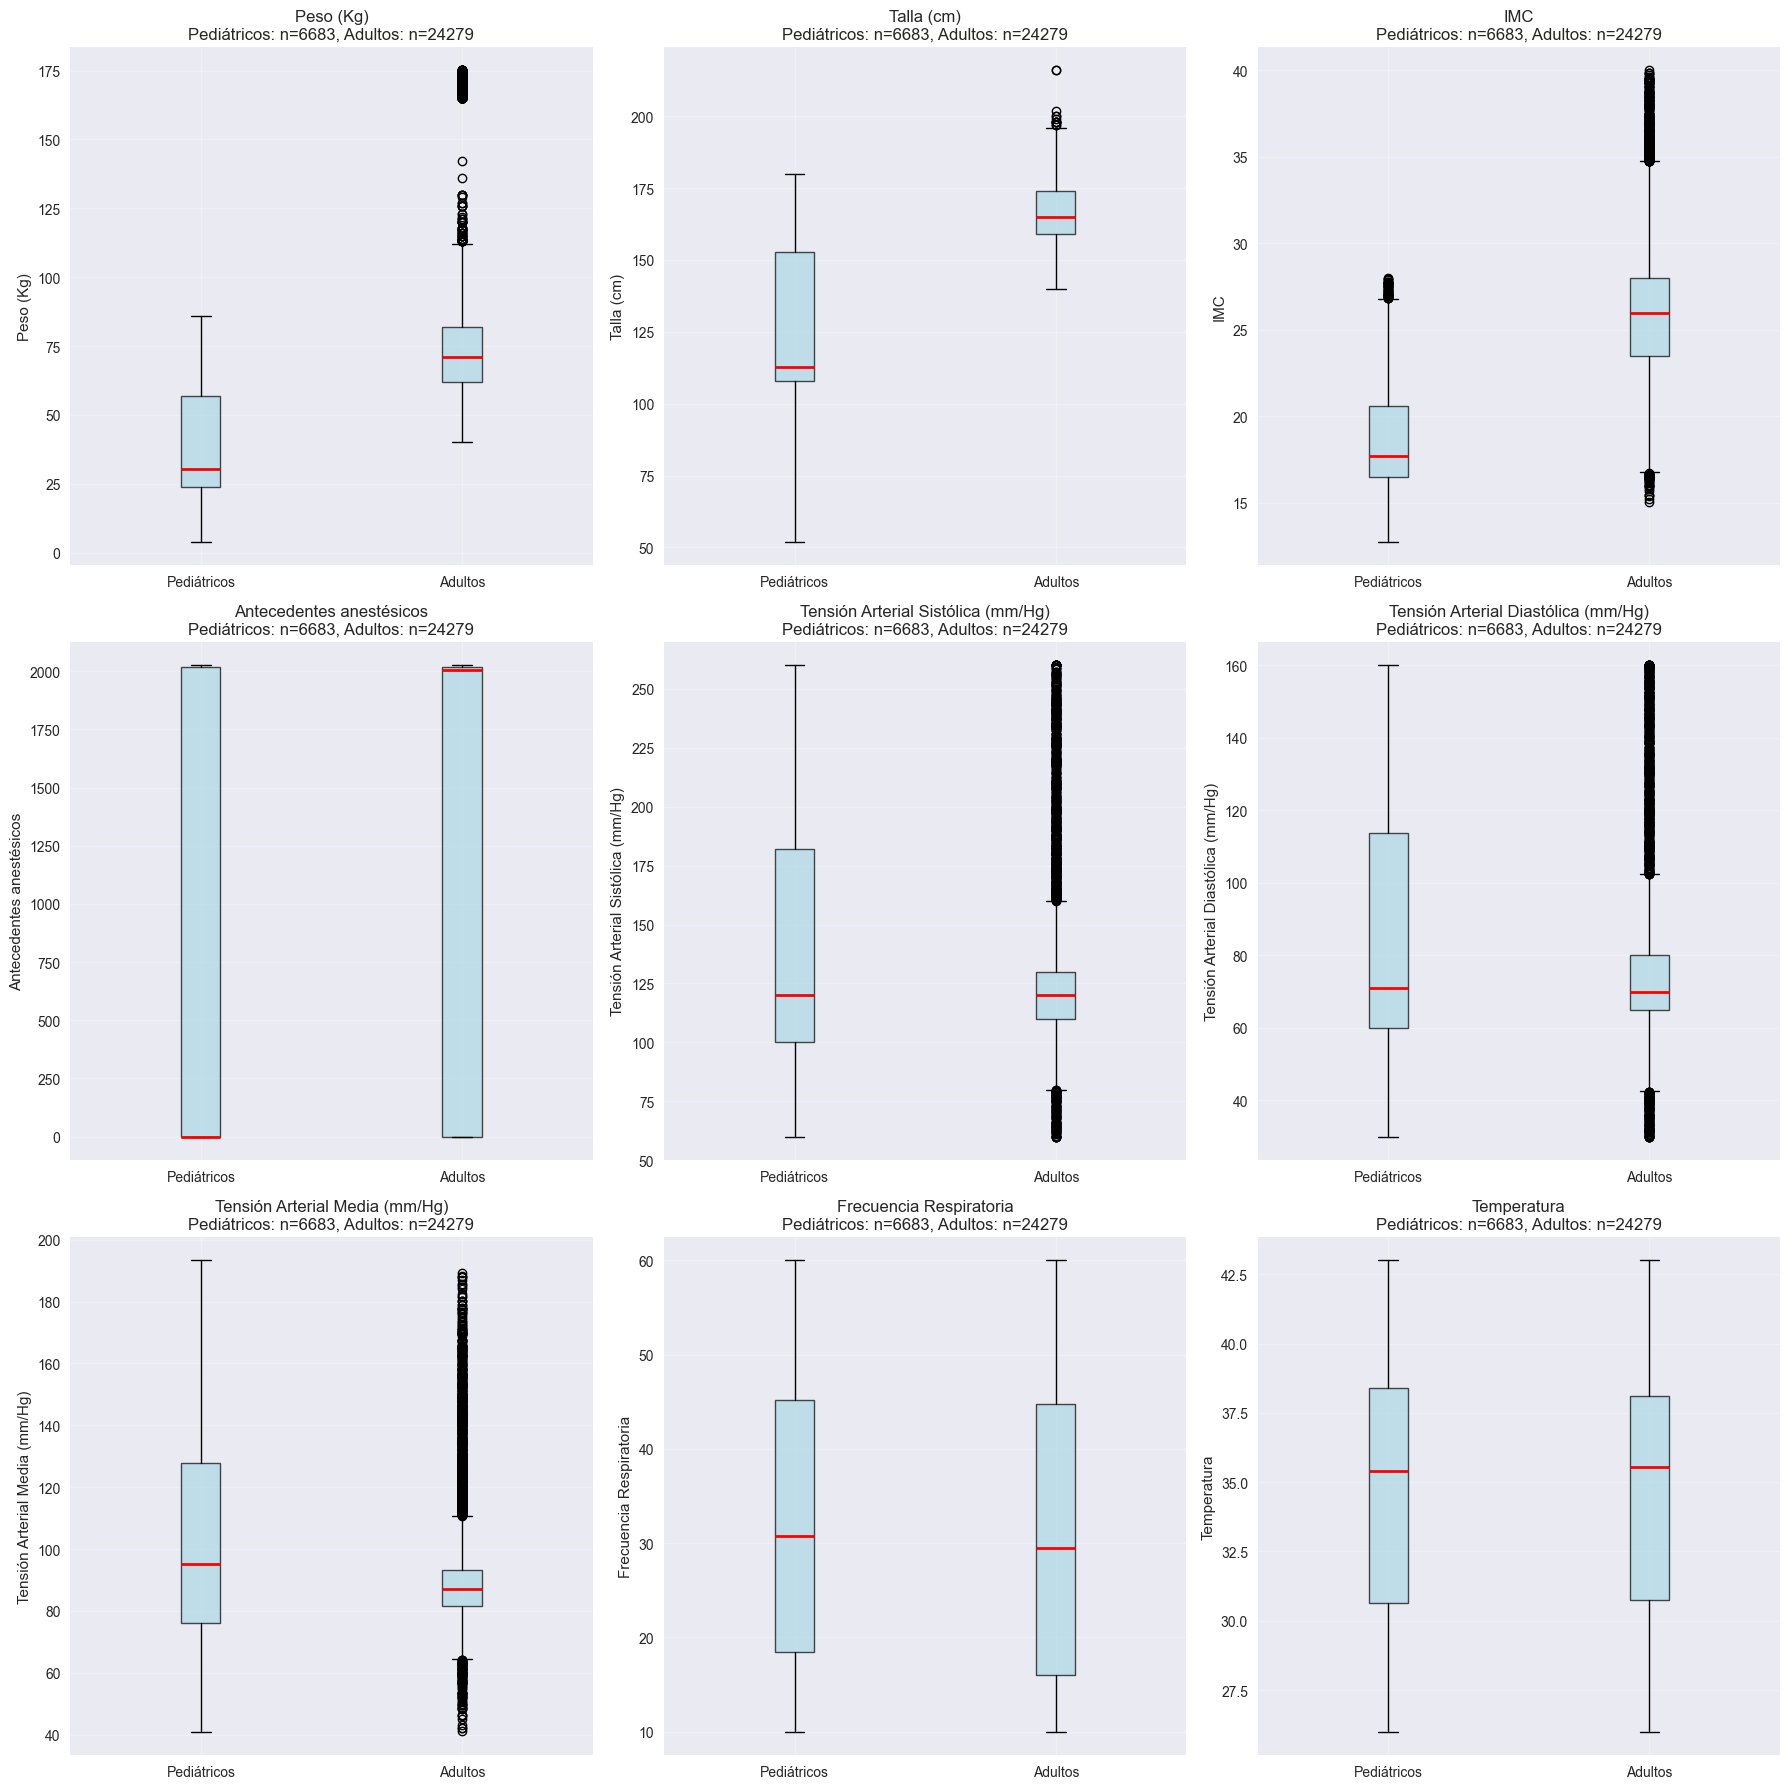

In [44]:
# Crear visualizaciones comparativas (solo para las primeras variables más importantes)
# Nota: Para evitar demasiadas visualizaciones, solo mostramos las primeras 9 variables
if df_clean is not None and 'Edad' in df_clean.columns and len(numeric_columns) > 0:
    # Seleccionar solo las primeras 9 variables para visualización
    numeric_columns_viz = numeric_columns[:9]
    n_cols = min(3, len(numeric_columns_viz))
    n_rows = (len(numeric_columns_viz) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
    if n_rows == 1:
        axes = [axes] if n_cols == 1 else axes
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(numeric_columns_viz):
        if i < len(axes):
            # Filtrar valores válidos
            ped_vals = df_pediatricos[col].dropna()
            adu_vals = df_adultos[col].dropna()
            
            if len(ped_vals) > 0 and len(adu_vals) > 0:
                # Boxplot comparativo
                data_to_plot = [ped_vals, adu_vals]
                bp = axes[i].boxplot(data_to_plot, labels=['Pediátricos', 'Adultos'], 
                                     patch_artist=True,
                                     boxprops=dict(facecolor='lightblue', alpha=0.7),
                                     medianprops=dict(color='red', linewidth=2))
                axes[i].set_ylabel(col)
                axes[i].set_title(f'{col}\nPediátricos: n={len(ped_vals)}, Adultos: n={len(adu_vals)}')
                axes[i].grid(True, alpha=0.3)
    
    # Ocultar subplots vacíos
    for i in range(len(numeric_columns_viz), len(axes)):
        axes[i].set_visible(False)
    
    print(f"\nNota: Mostrando solo las primeras {len(numeric_columns_viz)} variables de {len(numeric_columns)} totales")
    print(f"     Todas las {len(numeric_columns)} variables se usarán en el análisis de clustering/anomalías")
    
    plt.tight_layout()
    plt.show()


## 6. Análisis de Clustering por grupo de edad


In [ ]:
def analizar_clustering_anomalias(dataset, numeric_columns, grupo_nombre, contamination=0.02, kmeans_k=3):
    """
    Aplica PCA, clustering y detección de anomalías a un dataset.
    
    Returns:
        dict con resultados del análisis
    """
    # Preprocesamiento: solo filas completas y valores finitos
    X = dataset[numeric_columns].replace([np.inf, -np.inf], np.nan).dropna()
    
    if len(X) < 3:
        print(f"⚠️ {grupo_nombre}: No hay suficientes datos válidos para análisis avanzado.")
        return None
    
    print(f"\n{'='*60}")
    print(f"ANÁLISIS DE CLUSTERING Y ANOMALÍAS: {grupo_nombre}")
    print(f"{'='*60}")
    print(f"Registros válidos: {len(X)}")
    
    # Estandarización
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # PCA 3 componentes
    pca = PCA(n_components=10, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    explained_var = pca.explained_variance_ratio_.sum()
    print(f"Varianza explicada PCA: {explained_var:.2%}")
    print(f"Varianza por componente: PC1={pca.explained_variance_ratio_[0]:.2%}, "
          f"PC2={pca.explained_variance_ratio_[1]:.2%}, PC3={pca.explained_variance_ratio_[2]:.2%}")
    
    # Clustering
    kmeans = KMeans(n_clusters=kmeans_k, n_init=10, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    
    # Métricas de clustering
    silhouette = silhouette_score(X_scaled, clusters)
    calinski = calinski_harabasz_score(X_scaled, clusters)
    print(f"Silhouette Score: {silhouette:.3f}")
    print(f"Calinski-Harabasz Score: {calinski:.2f}")
    
    # Distribución de clusters
    cluster_counts = pd.Series(clusters).value_counts().sort_index()
    print(f"\nDistribución de clusters:")
    for cluster_id, count in cluster_counts.items():
        print(f"  Cluster {cluster_id}: {count} registros ({count/len(clusters)*100:.1f}%)")
    
    # Anomalías
    iso = IsolationForest(contamination=contamination, random_state=42)
    anomaly_labels = iso.fit_predict(X_scaled)  # -1 anomalía, 1 normal
    anomalies_mask = anomaly_labels == -1
    n_anomalias = anomalies_mask.sum()
    pct_anomalias = n_anomalias / len(X_scaled) * 100
    print(f"\nAnomalías detectadas: {n_anomalias} ({pct_anomalias:.1f}%)")
    
    # Anomalías por cluster
    if n_anomalias > 0:
        print(f"\nAnomalías por cluster:")
        for cluster_id in range(kmeans_k):
            mask_cluster = clusters == cluster_id
            mask_anom = anomalies_mask & mask_cluster
            n_anom_cluster = mask_anom.sum()
            if n_anom_cluster > 0:
                print(f"  Cluster {cluster_id}: {n_anom_cluster} anomalías "
                      f"({n_anom_cluster/mask_cluster.sum()*100:.1f}% del cluster)")
    
    return {
        'X': X,
        'X_scaled': X_scaled,
        'X_pca': X_pca,
        'pca': pca,
        'clusters': clusters,
        'kmeans': kmeans,
        'anomalies_mask': anomalies_mask,
        'iso': iso,
        'silhouette': silhouette,
        'calinski': calinski,
        'explained_var': explained_var,
        'n_anomalias': n_anomalias,
        'pct_anomalias': pct_anomalias
    }

# ============================================================================
# APLICAR ANÁLISIS DE CLUSTERING Y ANOMALÍAS A CADA GRUPO
# ============================================================================

if df_clean is not None and 'Edad' in df_clean.columns and len(numeric_columns) > 0:
    print("=" * 80)
    print(f"USANDO {len(numeric_columns)} VARIABLES NUMÉRICAS PARA CLUSTERING Y ANOMALÍAS")
    print("=" * 80)
    print("  (Incluye todas las variables codificadas del data cleaning)")
    
    # Aplicar análisis a cada grupo usando TODAS las variables numéricas
    resultados_ped = analizar_clustering_anomalias(
        df_pediatricos, 
        numeric_columns, 
        'PEDIÁTRICOS',
        contamination=0.02,
        kmeans_k=3
    )
    resultados_adu = analizar_clustering_anomalias(
        df_adultos, 
        numeric_columns, 
        'ADULTOS',
        contamination=0.02,
        kmeans_k=3
    )
else:
    print("✗ Error: No se pueden realizar análisis de clustering/anomalías")
    resultados_ped = None
    resultados_adu = None


USANDO 215 VARIABLES NUMÉRICAS PARA CLUSTERING Y ANOMALÍAS
  (Incluye todas las variables codificadas del data cleaning)

ANÁLISIS DE CLUSTERING Y ANOMALÍAS: PEDIÁTRICOS
Registros válidos: 6683
Varianza explicada PCA: 16.09%
Varianza por componente: PC1=2.70%, PC2=1.98%, PC3=1.91%
Silhouette Score: 0.072
Calinski-Harabasz Score: 120.43

Distribución de clusters:
  Cluster 0: 2425 registros (36.3%)
  Cluster 1: 149 registros (2.2%)
  Cluster 2: 4109 registros (61.5%)

Anomalías detectadas: 134 (2.0%)

Anomalías por cluster:
  Cluster 0: 87 anomalías (3.6% del cluster)
  Cluster 1: 30 anomalías (20.1% del cluster)
  Cluster 2: 17 anomalías (0.4% del cluster)

ANÁLISIS DE CLUSTERING Y ANOMALÍAS: ADULTOS
Registros válidos: 24279
Varianza explicada PCA: 14.23%
Varianza por componente: PC1=2.13%, PC2=2.03%, PC3=1.78%
Silhouette Score: 0.000
Calinski-Harabasz Score: 395.48

Distribución de clusters:
  Cluster 0: 8362 registros (34.4%)
  Cluster 1: 13497 registros (55.6%)
  Cluster 2: 2420 reg

## 7. Visualización de Clustering y Anomalías por grupo


In [46]:
def visualizar_clustering_anomalias(resultados, grupo_nombre):
    """Visualiza PCA, clustering y anomalías en 3D"""
    if resultados is None:
        return
    
    X_pca = resultados['X_pca']
    clusters = resultados['clusters']
    anomalies_mask = resultados['anomalies_mask']
    n_clusters = len(np.unique(clusters))
    
    # Colores para clusters
    colors_cluster = px.colors.qualitative.Set1[:n_clusters]
    cluster_colors = [colors_cluster[i] for i in clusters]
    
    # Crear subplots
    fig = make_subplots(
        rows=1, cols=3,
        specs=[[{'type': 'scene'}]*3],
        subplot_titles=[
            f'{grupo_nombre} - PCA (3D)',
            f'{grupo_nombre} - KMeans Clustering',
            f'{grupo_nombre} - Anomalías (IsolationForest)'
        ],
        horizontal_spacing=0.05
    )
    
    marker_size = 4 if len(X_pca) > 500 else 6
    
    # PCA puro
    fig.add_trace(
        go.Scatter3d(
            x=X_pca[:, 0], y=X_pca[:, 1], z=X_pca[:, 2],
            mode='markers',
            marker=dict(size=marker_size, color='royalblue', opacity=0.7),
            name='PCA',
            showlegend=False
        ),
        row=1, col=1
    )
    
    # Clustering
    for cluster_id in range(n_clusters):
        mask = clusters == cluster_id
        fig.add_trace(
            go.Scatter3d(
                x=X_pca[mask, 0], y=X_pca[mask, 1], z=X_pca[mask, 2],
                mode='markers',
                marker=dict(size=marker_size, color=colors_cluster[cluster_id], opacity=0.8),
                name=f'Cluster {cluster_id}',
                showlegend=True
            ),
            row=1, col=2
        )
    
    # Anomalías
    normal_mask = ~anomalies_mask
    fig.add_trace(
        go.Scatter3d(
            x=X_pca[normal_mask, 0], y=X_pca[normal_mask, 1], z=X_pca[normal_mask, 2],
            mode='markers',
            marker=dict(size=marker_size, color='lightgrey', opacity=0.5),
            name='Normal',
            showlegend=True
        ),
        row=1, col=3
    )
    if anomalies_mask.sum() > 0:
        fig.add_trace(
            go.Scatter3d(
                x=X_pca[anomalies_mask, 0], y=X_pca[anomalies_mask, 1], z=X_pca[anomalies_mask, 2],
                mode='markers',
                marker=dict(size=marker_size+2, color='red', opacity=0.9),
                name='Anomalía',
                showlegend=True
            ),
            row=1, col=3
        )
    
    # Etiquetas de ejes
    for i in range(1, 4):
        fig['layout'][f'scene{i}']['xaxis']['title'] = 'PC1'
        fig['layout'][f'scene{i}']['yaxis']['title'] = 'PC2'
        fig['layout'][f'scene{i}']['zaxis']['title'] = 'PC3'
    
    fig.update_layout(
        title=f"{grupo_nombre} - Análisis de Clustering y Anomalías",
        height=500,
        width=1500,
        margin=dict(t=50, l=10, r=10, b=10)
    )
    
    fig.show()

# Visualizar resultados
if resultados_ped is not None:
    visualizar_clustering_anomalias(resultados_ped, 'PEDIÁTRICOS')

if resultados_adu is not None:
    visualizar_clustering_anomalias(resultados_adu, 'ADULTOS')


In [47]:
# Comparar métricas de clustering y anomalías entre grupos
if resultados_ped is not None and resultados_adu is not None:
    print("=" * 80)
    print("COMPARACIÓN DE RESULTADOS DE CLUSTERING Y ANOMALÍAS")
    print("=" * 80)
    
    comparacion = pd.DataFrame({
        'Métrica': [
            'Varianza explicada PCA',
            'Silhouette Score',
            'Calinski-Harabasz Score',
            'Número de anomalías',
            'Porcentaje de anomalías',
            'Número de registros válidos'
        ],
        'Pediátricos': [
            f"{resultados_ped['explained_var']:.2%}",
            f"{resultados_ped['silhouette']:.3f}",
            f"{resultados_ped['calinski']:.2f}",
            resultados_ped['n_anomalias'],
            f"{resultados_ped['pct_anomalias']:.2f}%",
            len(resultados_ped['X'])
        ],
        'Adultos': [
            f"{resultados_adu['explained_var']:.2%}",
            f"{resultados_adu['silhouette']:.3f}",
            f"{resultados_adu['calinski']:.2f}",
            resultados_adu['n_anomalias'],
            f"{resultados_adu['pct_anomalias']:.2f}%",
            len(resultados_adu['X'])
        ]
    })
    
    print(comparacion.to_string(index=False))
    
    # Análisis de diferencias
    print("\n" + "=" * 80)
    print("ANÁLISIS DE DIFERENCIAS")
    print("=" * 80)
    
    diff_var = abs(resultados_ped['explained_var'] - resultados_adu['explained_var'])
    print(f"• Diferencia en varianza explicada PCA: {diff_var:.2%}")
    if diff_var > 0.05:
        print("  → Diferencia notable: Los grupos tienen estructuras diferentes en el espacio PCA")
    else:
        print("  → Diferencia pequeña: Estructuras similares en el espacio PCA")
    
    diff_sil = abs(resultados_ped['silhouette'] - resultados_adu['silhouette'])
    print(f"\n• Diferencia en Silhouette Score: {diff_sil:.3f}")
    if diff_sil > 0.1:
        print("  → Diferencia notable: Calidad de clustering diferente entre grupos")
    else:
        print("  → Diferencia pequeña: Calidad de clustering similar")
    
    diff_anom = abs(resultados_ped['pct_anomalias'] - resultados_adu['pct_anomalias'])
    print(f"\n• Diferencia en porcentaje de anomalías: {diff_anom:.2f}%")
    if diff_anom > 1.0:
        print("  → Diferencia notable: Proporción de anomalías diferente entre grupos")
    else:
        print("  → Diferencia pequeña: Proporción de anomalías similar")
    
    # Recomendación
    print("\n" + "=" * 80)
    print("RECOMENDACIÓN")
    print("=" * 80)
    
    if diff_var > 0.05 or diff_sil > 0.1 or diff_anom > 1.0:
        print("✓ Se recomienda SEPARAR el modelo en dos:")
        print("  - Modelo para pacientes pediátricos (< 18 años)")
        print("  - Modelo para pacientes adultos (≥ 18 años)")
        print("\nRazones:")
        if diff_var > 0.05:
            print("  • Estructura de datos diferente en el espacio PCA")
        if diff_sil > 0.1:
            print("  • Calidad de clustering diferente")
        if diff_anom > 1.0:
            print("  • Proporción de anomalías diferente")
    else:
        print("✓ Los grupos son suficientemente similares para usar un modelo único")
        print("  Sin embargo, se puede considerar separar por edad si:")
        print("  - Hay diferencias clínicas significativas")
        print("  - Se requiere mayor precisión en la detección de anomalías")


COMPARACIÓN DE RESULTADOS DE CLUSTERING Y ANOMALÍAS
                    Métrica Pediátricos Adultos
     Varianza explicada PCA      16.09%  14.23%
           Silhouette Score       0.072   0.000
    Calinski-Harabasz Score      120.43  395.48
        Número de anomalías         134     486
    Porcentaje de anomalías       2.01%   2.00%
Número de registros válidos        6683   24279

ANÁLISIS DE DIFERENCIAS
• Diferencia en varianza explicada PCA: 1.86%
  → Diferencia pequeña: Estructuras similares en el espacio PCA

• Diferencia en Silhouette Score: 0.071
  → Diferencia pequeña: Calidad de clustering similar

• Diferencia en porcentaje de anomalías: 0.00%
  → Diferencia pequeña: Proporción de anomalías similar

RECOMENDACIÓN
✓ Los grupos son suficientemente similares para usar un modelo único
  Sin embargo, se puede considerar separar por edad si:
  - Hay diferencias clínicas significativas
  - Se requiere mayor precisión en la detección de anomalías


## 9. Análisis de anomalías: Comparación detallada


In [48]:
def analizar_anomalias_detallado(resultados, dataset_original, grupo_nombre, numeric_columns):
    """Analiza las características de las anomalías detectadas"""
    if resultados is None:
        return None
    
    X = resultados['X']
    anomalies_mask = resultados['anomalies_mask']
    iso = resultados['iso']
    
    # Obtener índices originales
    indices_validos = X.index
    anomalias_indices = indices_validos[anomalies_mask]
    normales_indices = indices_validos[~anomalies_mask]
    
    # Obtener datos originales
    anomalias_df = dataset_original.loc[anomalias_indices].copy()
    normales_df = dataset_original.loc[normales_indices].copy()
    
    # Calcular scores de anomalía
    X_scaled = resultados['X_scaled']
    anomaly_scores = -iso.decision_function(X_scaled[anomalies_mask])
    anomalias_df['__anomaly_score'] = anomaly_scores
    anomalias_df['__anomaly_rank'] = anomalias_df['__anomaly_score'].rank(ascending=False)
    
    print(f"\n{'='*80}")
    print(f"ANÁLISIS DETALLADO DE ANOMALÍAS: {grupo_nombre}")
    print(f"{'='*80}")
    
    # Comparar estadísticas de anomalías vs normales
    print("\nComparación de variables numéricas (Anomalías vs Normales):")
    comparacion_anom = []
    
    for col in numeric_columns:
        if col in anomalias_df.columns and col in normales_df.columns:
            anom_vals = anomalias_df[col].dropna()
            norm_vals = normales_df[col].dropna()
            
            if len(anom_vals) > 0 and len(norm_vals) > 0:
                comparacion_anom.append({
                    'Variable': col,
                    'Media_Anomalias': anom_vals.mean(),
                    'Media_Normales': norm_vals.mean(),
                    'Diferencia': anom_vals.mean() - norm_vals.mean(),
                    'N_Anomalias': len(anom_vals),
                    'N_Normales': len(norm_vals)
                })
    
    if comparacion_anom:
        comp_df = pd.DataFrame(comparacion_anom)
        comp_df = comp_df.sort_values('Diferencia', key=abs, ascending=False)
        print(comp_df.to_string(index=False))
    
    # Top 5 anomalías más extremas (mostrar solo variables principales)
    print(f"\nTop 5 anomalías más extremas (por score):")
    # Seleccionar solo algunas columnas principales para mostrar
    columnas_mostrar = ['Edad'] + [col for col in ['Peso (Kg)', 'Talla (cm)', 'IMC', 
                                                   'Tensión Arterial Sistólica (mm/Hg)',
                                                   'Tensión Arterial Diastólica (mm/Hg)',
                                                   'Frecuencia Respiratoria', 'Temperatura']
                                   if col in anomalias_df.columns] + ['__anomaly_score']
    top_anomalias = anomalias_df.nlargest(5, '__anomaly_score')
    print(top_anomalias[columnas_mostrar].to_string())
    
    return {
        'anomalias_df': anomalias_df,
        'normales_df': normales_df,
        'comparacion': comp_df if comparacion_anom else None
    }

# Analizar anomalías en detalle
if resultados_ped is not None:
    detalle_ped = analizar_anomalias_detallado(resultados_ped, df_pediatricos, 'PEDIÁTRICOS', numeric_columns)

if resultados_adu is not None:
    detalle_adu = analizar_anomalias_detallado(resultados_adu, df_adultos, 'ADULTOS', numeric_columns)



ANÁLISIS DETALLADO DE ANOMALÍAS: PEDIÁTRICOS

Comparación de variables numéricas (Anomalías vs Normales):
                                       Variable  Media_Anomalias  Media_Normales  Diferencia  N_Anomalias  N_Normales
                       Antecedentes anestésicos      1702.440299      741.902581  960.537718          134        6549
                                     Talla (cm)       132.536337      123.923983    8.612354          134        6549
                                      Peso (Kg)        43.113373       36.560020    6.553353          134        6549
            Tensión Arterial Diastólica (mm/Hg)        80.478265       85.199985   -4.721720          134        6549
             Tensión Arterial Sistólica (mm/Hg)       143.484140      140.590512    2.893628          134        6549
                        Examen_Glicemia (mg/dl)         2.656716        0.373538    2.283178          134        6549
                 Tensión Arterial Media (mm/Hg)       101.477736   

## 10. Experimentación: Clustering y Anomalías con diferentes configuraciones


EXPERIMENTACIÓN: Diferentes configuraciones de clustering

Resultados de experimentación:
      Grupo  K  Silhouette  Calinski-Harabasz
Pediátricos  2    0.077276         164.219844
Pediátricos  3    0.071550         120.434533
Pediátricos  4    0.037863         108.335697
Pediátricos  5    0.061766          98.649696
    Adultos  2    0.015265         466.630731
    Adultos  3    0.000372         395.481402
    Adultos  4    0.010025         332.582111
    Adultos  5   -0.007177         315.845183


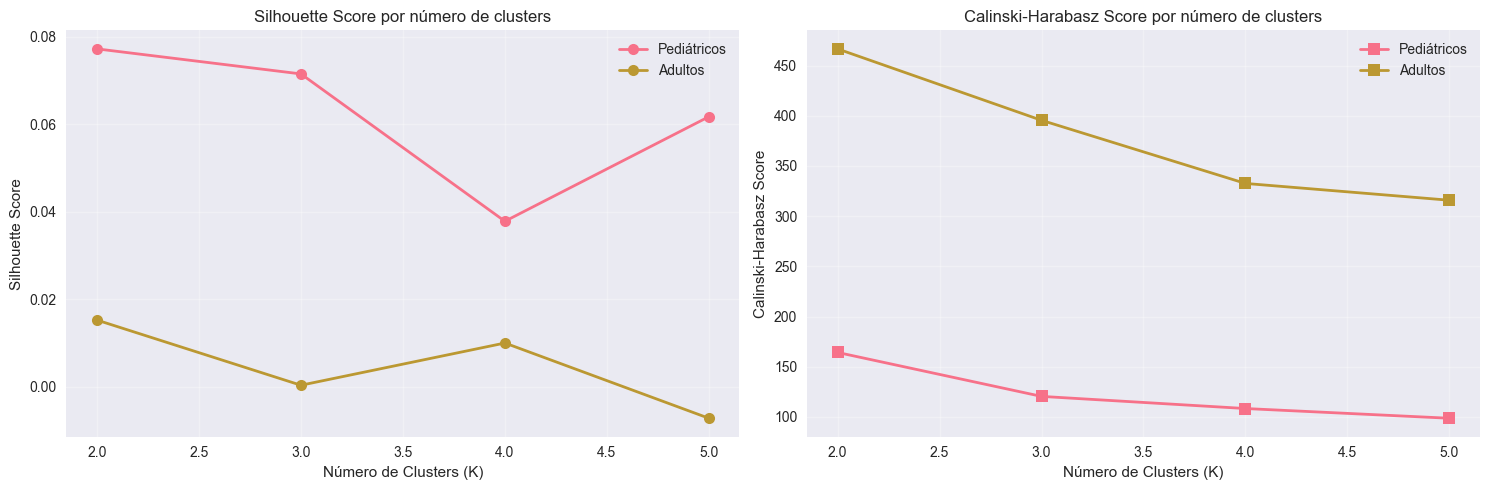


MEJOR CONFIGURACIÓN DE CLUSTERS

Pediátricos:
  Mejor K según Silhouette: 2
  Mejor K según Calinski-Harabasz: 2

Adultos:
  Mejor K según Silhouette: 2
  Mejor K según Calinski-Harabasz: 2


In [49]:
# Experimentar con diferentes configuraciones de clustering y anomalías
print("=" * 80)
print("EXPERIMENTACIÓN: Diferentes configuraciones de clustering")
print("=" * 80)

def experimentar_clustering(dataset, numeric_columns, grupo_nombre, k_values=[2, 3, 4, 5]):
    """Experimenta con diferentes números de clusters"""
    X = dataset[numeric_columns].replace([np.inf, -np.inf], np.nan).dropna()
    
    if len(X) < 3:
        return None
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    resultados_exp = []
    
    for k in k_values:
        if k >= len(X):
            continue
            
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
        clusters = kmeans.fit_predict(X_scaled)
        
        silhouette = silhouette_score(X_scaled, clusters)
        calinski = calinski_harabasz_score(X_scaled, clusters)
        
        resultados_exp.append({
            'Grupo': grupo_nombre,
            'K': k,
            'Silhouette': silhouette,
            'Calinski-Harabasz': calinski
        })
    
    return pd.DataFrame(resultados_exp)

# Experimentar con ambos grupos (usando TODAS las variables numéricas)
if df_clean is not None and 'Edad' in df_clean.columns and len(numeric_columns) > 0:
    exp_ped = experimentar_clustering(df_pediatricos, numeric_columns, 'Pediátricos')
    exp_adu = experimentar_clustering(df_adultos, numeric_columns, 'Adultos')
    
    if exp_ped is not None and exp_adu is not None:
        exp_combinado = pd.concat([exp_ped, exp_adu], ignore_index=True)
        print("\nResultados de experimentación:")
        print(exp_combinado.to_string(index=False))
        
        # Visualizar
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Silhouette Score
        for grupo in ['Pediátricos', 'Adultos']:
            data = exp_combinado[exp_combinado['Grupo'] == grupo]
            axes[0].plot(data['K'], data['Silhouette'], marker='o', label=grupo, linewidth=2, markersize=8)
        axes[0].set_xlabel('Número de Clusters (K)')
        axes[0].set_ylabel('Silhouette Score')
        axes[0].set_title('Silhouette Score por número de clusters')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Calinski-Harabasz Score
        for grupo in ['Pediátricos', 'Adultos']:
            data = exp_combinado[exp_combinado['Grupo'] == grupo]
            axes[1].plot(data['K'], data['Calinski-Harabasz'], marker='s', label=grupo, linewidth=2, markersize=8)
        axes[1].set_xlabel('Número de Clusters (K)')
        axes[1].set_ylabel('Calinski-Harabasz Score')
        axes[1].set_title('Calinski-Harabasz Score por número de clusters')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Mejor K para cada grupo
        print("\n" + "=" * 80)
        print("MEJOR CONFIGURACIÓN DE CLUSTERS")
        print("=" * 80)
        for grupo in ['Pediátricos', 'Adultos']:
            data = exp_combinado[exp_combinado['Grupo'] == grupo]
            mejor_k_sil = data.loc[data['Silhouette'].idxmax(), 'K']
            mejor_k_cal = data.loc[data['Calinski-Harabasz'].idxmax(), 'K']
            print(f"\n{grupo}:")
            print(f"  Mejor K según Silhouette: {int(mejor_k_sil)}")
            print(f"  Mejor K según Calinski-Harabasz: {int(mejor_k_cal)}")


## 11. Análisis de variables categóricas por grupo de edad


In [ ]:
# ============================================================================
# ANÁLISIS DE VARIABLES CATEGÓRICAS (usando dataset original)
# ============================================================================

categorical_columns = ['Sexo', 'Atención', 'Grupo Sanguíneo', 'RH', 'Medicamentos', 'Alergias',
                       'Cuello Móvil', 'Prótesis Dental', 'Apertura Oral', 'Estado Nutricional',
                       'Arritmia', 'Disnea', 'Angina']

if df_original is not None:
    # Separar dataset original por edad también
    df_original_pediatricos, df_original_adultos = separar_por_edad(df_original, edad_col='Edad', umbral=EDAD_UMBRAL)
    
    # Filtrar solo las que existen en el dataset original
    categorical_columns = [col for col in categorical_columns if col in df_original.columns]
    
    print(f"✓ Analizando {len(categorical_columns)} variables categóricas del dataset original")
    print(f"  Pediátricos: {len(df_original_pediatricos)} registros")
    print(f"  Adultos: {len(df_original_adultos)} registros")
else:
    categorical_columns = []
    df_original_pediatricos = None
    df_original_adultos = None
    print("⚠ Advertencia: No se puede realizar análisis categórico (dataset original no disponible)")

def comparar_categoricas(df_ped, df_adu, columnas):
    """Compara variables categóricas entre grupos usando chi-cuadrado"""
    resultados = []
    
    for col in columnas:
        # Crear tabla de contingencia
        tabla = pd.crosstab(df_ped[col].fillna('Sin dato'), 
                           pd.Series(['Pediátricos'] * len(df_ped), index=df_ped.index))
        tabla['Adultos'] = pd.crosstab(df_adu[col].fillna('Sin dato'), 
                                      pd.Series(['Adultos'] * len(df_adu), index=df_adu.index))['Adultos']
        
        # Calcular porcentajes
        tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100
        
        # Test chi-cuadrado
        try:
            chi2, p_value, dof, expected = chi2_contingency(tabla)
            resultados.append({
                'Variable': col,
                'Chi2': f"{chi2:.3f}",
                'p_value': f"{p_value:.6f}",
                'Significativo': 'Sí' if p_value < 0.05 else 'No',
                'N_Ped': len(df_ped[col].dropna()),
                'N_Adu': len(df_adu[col].dropna())
            })
        except:
            resultados.append({
                'Variable': col,
                'Chi2': 'N/A',
                'p_value': 'N/A',
                'Significativo': 'N/A',
                'N_Ped': len(df_ped[col].dropna()),
                'N_Adu': len(df_adu[col].dropna())
            })
    
    return pd.DataFrame(resultados)

if df_original is not None and len(categorical_columns) > 0:
    resultados_cat = comparar_categoricas(df_original_pediatricos, df_original_adultos, categorical_columns)
    print("=" * 80)
    print("COMPARACIÓN DE VARIABLES CATEGÓRICAS")
    print("=" * 80)
    print(resultados_cat.to_string(index=False))
    
    # Mostrar diferencias significativas
    significativas_cat = resultados_cat[resultados_cat['Significativo'] == 'Sí']
    if len(significativas_cat) > 0:
        print("\n" + "=" * 80)
        print("VARIABLES CATEGÓRICAS CON DIFERENCIAS SIGNIFICATIVAS")
        print("=" * 80)
        print(significativas_cat[['Variable', 'p_value']].to_string(index=False))


✓ Analizando 13 variables categóricas del dataset original
  Pediátricos: 6683 registros
  Adultos: 24279 registros
COMPARACIÓN DE VARIABLES CATEGÓRICAS
          Variable    Chi2  p_value Significativo  N_Ped  N_Adu
              Sexo 558.471 0.000000            Sí   6683  24279
          Atención   0.497 0.779788            No   6683  24279
   Grupo Sanguíneo 152.467 0.000000            Sí   6683  24279
                RH 152.905 0.000000            Sí   6683  24279
      Medicamentos 226.803 0.000000            Sí   6683  24279
          Alergias 151.849 0.000000            Sí   6683  24279
      Cuello Móvil  47.144 0.000000            Sí   6683  24279
   Prótesis Dental 981.462 0.000000            Sí   6683  24279
     Apertura Oral 961.867 0.000000            Sí   6683  24279
Estado Nutricional 267.124 0.000000            Sí   6683  24279
          Arritmia   7.099 0.007713            Sí   6683  24279
            Disnea   0.038 0.845472            No      1      7
            Ang

## 12. Resumen y Conclusiones


In [51]:
print("=" * 80)
print("RESUMEN EJECUTIVO DEL ANÁLISIS")
print("=" * 80)

if 'Edad' in df.columns:
    print(f"\n1. DISTRIBUCIÓN DE DATOS:")
    print(f"   • Total de registros: {len(df)}")
    print(f"   • Pediátricos (< 18 años): {len(df_pediatricos)} ({len(df_pediatricos)/len(df)*100:.2f}%)")
    print(f"   • Adultos (≥ 18 años): {len(df_adultos)} ({len(df_adultos)/len(df)*100:.2f}%)")
    
    if resultados_ped is not None and resultados_adu is not None:
        print(f"\n2. ANÁLISIS DE CLUSTERING:")
        print(f"   • Varianza explicada PCA - Pediátricos: {resultados_ped['explained_var']:.2%}")
        print(f"   • Varianza explicada PCA - Adultos: {resultados_adu['explained_var']:.2%}")
        print(f"   • Diferencia: {abs(resultados_ped['explained_var'] - resultados_adu['explained_var']):.2%}")
        print(f"   • Silhouette Score - Pediátricos: {resultados_ped['silhouette']:.3f}")
        print(f"   • Silhouette Score - Adultos: {resultados_adu['silhouette']:.3f}")
        
        print(f"\n3. DETECCIÓN DE ANOMALÍAS:")
        print(f"   • Anomalías Pediátricos: {resultados_ped['n_anomalias']} ({resultados_ped['pct_anomalias']:.2f}%)")
        print(f"   • Anomalías Adultos: {resultados_adu['n_anomalias']} ({resultados_adu['pct_anomalias']:.2f}%)")
        print(f"   • Diferencia en %: {abs(resultados_ped['pct_anomalias'] - resultados_adu['pct_anomalias']):.2f}%")
        
        print(f"\n4. RECOMENDACIONES:")
        diff_var = abs(resultados_ped['explained_var'] - resultados_adu['explained_var'])
        diff_sil = abs(resultados_ped['silhouette'] - resultados_adu['silhouette'])
        diff_anom = abs(resultados_ped['pct_anomalias'] - resultados_adu['pct_anomalias'])
        
        if diff_var > 0.05 or diff_sil > 0.1 or diff_anom > 1.0:
            print("   ✓ SEPARAR el modelo en dos grupos:")
            print("     - Modelo pediátrico (< 18 años)")
            print("     - Modelo adulto (≥ 18 años)")
            print("\n   Justificación:")
            if diff_var > 0.05:
                print(f"     • Estructura PCA diferente (diferencia: {diff_var:.2%})")
            if diff_sil > 0.1:
                print(f"     • Calidad de clustering diferente (diferencia: {diff_sil:.3f})")
            if diff_anom > 1.0:
                print(f"     • Proporción de anomalías diferente (diferencia: {diff_anom:.2f}%)")
        else:
            print("   • Los grupos son similares estadísticamente")
            print("   • Se puede usar un modelo único, pero considerar separar si:")
            print("     - Hay diferencias clínicas significativas")
            print("     - Se requiere mayor precisión")
        
        print(f"\n5. PRÓXIMOS PASOS SUGERIDOS:")
        print("   • Validar los modelos separados con datos de prueba")
        print("   • Comparar métricas de rendimiento entre modelo único vs separado")
        print("   • Analizar características específicas de anomalías en cada grupo")
        print("   • Considerar subgrupos adicionales (ej: neonatos, adolescentes)")


RESUMEN EJECUTIVO DEL ANÁLISIS

1. DISTRIBUCIÓN DE DATOS:
   • Total de registros: 30962
   • Pediátricos (< 18 años): 6683 (21.58%)
   • Adultos (≥ 18 años): 24279 (78.42%)

2. ANÁLISIS DE CLUSTERING:
   • Varianza explicada PCA - Pediátricos: 16.09%
   • Varianza explicada PCA - Adultos: 14.23%
   • Diferencia: 1.86%
   • Silhouette Score - Pediátricos: 0.072
   • Silhouette Score - Adultos: 0.000

3. DETECCIÓN DE ANOMALÍAS:
   • Anomalías Pediátricos: 134 (2.01%)
   • Anomalías Adultos: 486 (2.00%)
   • Diferencia en %: 0.00%

4. RECOMENDACIONES:
   • Los grupos son similares estadísticamente
   • Se puede usar un modelo único, pero considerar separar si:
     - Hay diferencias clínicas significativas
     - Se requiere mayor precisión

5. PRÓXIMOS PASOS SUGERIDOS:
   • Validar los modelos separados con datos de prueba
   • Comparar métricas de rendimiento entre modelo único vs separado
   • Analizar características específicas de anomalías en cada grupo
   • Considerar subgrupos ad

## 13. Análisis adicional: Clustering con dataset completo vs separado


In [52]:
# Comparar clustering del dataset completo vs separado por edad
print("=" * 80)
print("COMPARACIÓN: Dataset Completo vs Separado por Edad")
print("=" * 80)

if 'Edad' in df.columns and len(numeric_columns) > 0:
    # Análisis con dataset completo
    print("\n1. ANÁLISIS CON DATASET COMPLETO (sin separar por edad):")
    resultados_completo = analizar_clustering_anomalias(df, numeric_columns, 'DATASET COMPLETO')
    
    # Comparar resultados
    if resultados_completo is not None and resultados_ped is not None and resultados_adu is not None:
        print("\n" + "=" * 80)
        print("COMPARACIÓN DE MÉTRICAS")
        print("=" * 80)
        
        comparacion_completo = pd.DataFrame({
            'Métrica': [
                'Varianza explicada PCA',
                'Silhouette Score',
                'Calinski-Harabasz Score',
                'Porcentaje de anomalías',
                'Número de registros'
            ],
            'Dataset Completo': [
                f"{resultados_completo['explained_var']:.2%}",
                f"{resultados_completo['silhouette']:.3f}",
                f"{resultados_completo['calinski']:.2f}",
                f"{resultados_completo['pct_anomalias']:.2f}%",
                len(resultados_completo['X'])
            ],
            'Pediátricos (Separado)': [
                f"{resultados_ped['explained_var']:.2%}",
                f"{resultados_ped['silhouette']:.3f}",
                f"{resultados_ped['calinski']:.2f}",
                f"{resultados_ped['pct_anomalias']:.2f}%",
                len(resultados_ped['X'])
            ],
            'Adultos (Separado)': [
                f"{resultados_adu['explained_var']:.2%}",
                f"{resultados_adu['silhouette']:.3f}",
                f"{resultados_adu['calinski']:.2f}",
                f"{resultados_adu['pct_anomalias']:.2f}%",
                len(resultados_adu['X'])
            ]
        })
        
        print(comparacion_completo.to_string(index=False))
        
        # Análisis de si es mejor separar
        print("\n" + "=" * 80)
        print("EVALUACIÓN: ¿Es mejor separar por edad?")
        print("=" * 80)
        
        # Calcular promedio ponderado de métricas separadas
        n_ped = len(resultados_ped['X'])
        n_adu = len(resultados_adu['X'])
        n_total = n_ped + n_adu
        
        sil_promedio = (resultados_ped['silhouette'] * n_ped + resultados_adu['silhouette'] * n_adu) / n_total
        var_promedio = (resultados_ped['explained_var'] * n_ped + resultados_adu['explained_var'] * n_adu) / n_total
        
        print(f"\nMétricas promedio ponderado (separado):")
        print(f"  Silhouette Score: {sil_promedio:.3f} (vs {resultados_completo['silhouette']:.3f} completo)")
        print(f"  Varianza PCA: {var_promedio:.2%} (vs {resultados_completo['explained_var']:.2%} completo)")
        
        mejora_sil = sil_promedio - resultados_completo['silhouette']
        mejora_var = var_promedio - resultados_completo['explained_var']
        
        print(f"\nMejora al separar:")
        print(f"  Silhouette: {mejora_sil:+.3f} ({'Mejora' if mejora_sil > 0 else 'Empeora'})")
        print(f"  Varianza PCA: {mejora_var:+.2%} ({'Mejora' if mejora_var > 0 else 'Empeora'})")
        
        if mejora_sil > 0.05 or mejora_var > 0.05:
            print("\n✓ CONCLUSIÓN: Separar por edad MEJORA significativamente el clustering")
        elif mejora_sil < -0.05 or mejora_var < -0.05:
            print("\n✓ CONCLUSIÓN: El dataset completo funciona MEJOR que separar")
        else:
            print("\n✓ CONCLUSIÓN: No hay diferencia significativa entre ambos enfoques")
            print("  Se puede usar cualquiera, pero separar puede ser útil para:")
            print("  - Interpretación clínica más específica")
            print("  - Detección de anomalías más precisa por grupo")


COMPARACIÓN: Dataset Completo vs Separado por Edad

1. ANÁLISIS CON DATASET COMPLETO (sin separar por edad):

ANÁLISIS DE CLUSTERING Y ANOMALÍAS: DATASET COMPLETO
Registros válidos: 30962
Varianza explicada PCA: 14.36%
Varianza por componente: PC1=2.43%, PC2=1.90%, PC3=1.77%
Silhouette Score: 0.013
Calinski-Harabasz Score: 545.67

Distribución de clusters:
  Cluster 0: 13352 registros (43.1%)
  Cluster 1: 10808 registros (34.9%)
  Cluster 2: 6802 registros (22.0%)

Anomalías detectadas: 620 (2.0%)

Anomalías por cluster:
  Cluster 0: 228 anomalías (1.7% del cluster)
  Cluster 1: 83 anomalías (0.8% del cluster)
  Cluster 2: 309 anomalías (4.5% del cluster)

COMPARACIÓN DE MÉTRICAS
                Métrica Dataset Completo Pediátricos (Separado) Adultos (Separado)
 Varianza explicada PCA           14.36%                 16.09%             14.23%
       Silhouette Score            0.013                  0.072              0.000
Calinski-Harabasz Score           545.67                 120.4